Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.5027 - loss: 0.7730 - val_accuracy: 0.8791 - val_loss: 0.5251
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8434 - loss: 0.4628 - val_accuracy: 0.9560 - val_loss: 0.3424
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9203 - loss: 0.3155 - val_accuracy: 0.9560 - val_loss: 0.2421
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9368 - loss: 0.2510 - val_accuracy: 0.9670 - val_loss: 0.1806
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9588 - loss: 0.1843 - val_accuracy: 0.9670 - val_loss: 0.1434
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9505 - loss: 0.1769 - val_accuracy: 0.9670 - val_loss: 0.1192
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9698 - loss: 0.1471 - val_accuracy: 0.9780 - val_loss: 0.1019
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9588 - loss: 0.1337 - val_accuracy: 0.9780 - v

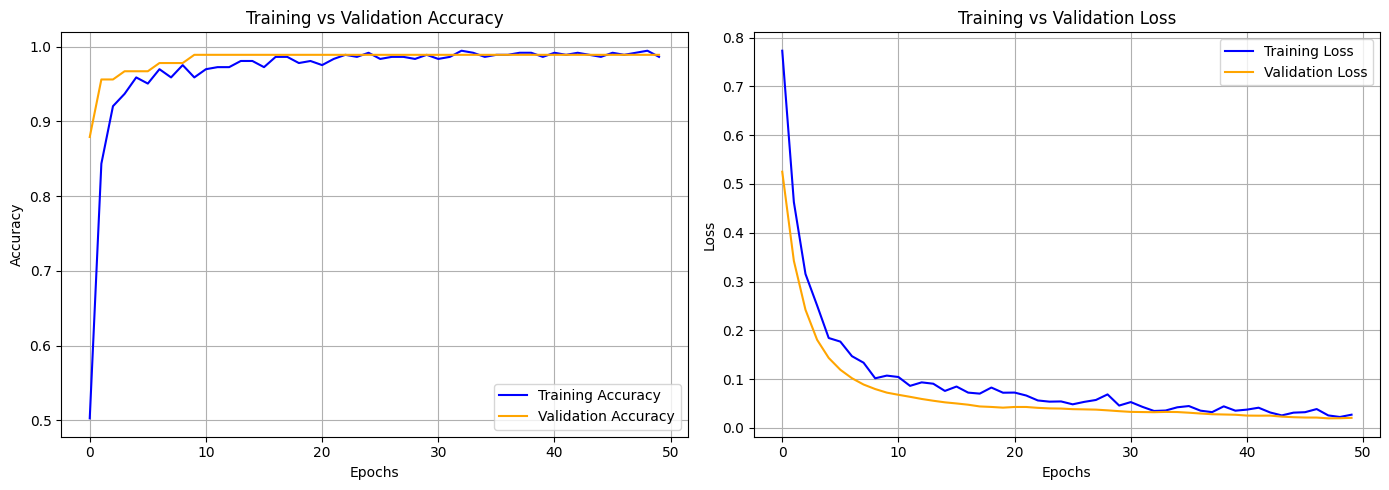


---> Test Accuracy: 95.61%
---> Test Loss: 0.1156

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
=== Top 5 Sample Predictions ===
Actual Label Predicted Label  Predicted Probability (Malignant/Benign)
   malignant       malignant                                    0.0000
      benign          benign                                    1.0000
   malignant       malignant                                    0.0000
      benign       malignant                                    0.0501
   malignant       malignant                                    0.0000


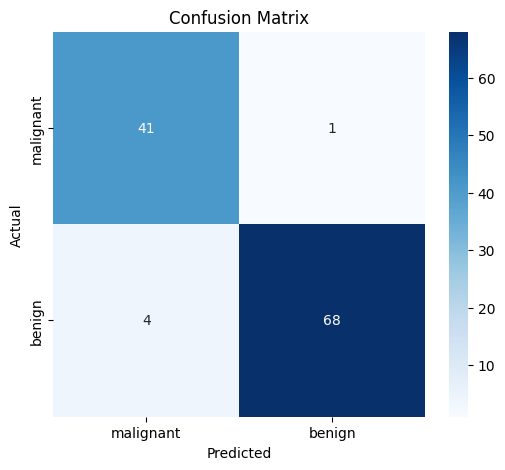


=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================
# 1. LOAD AND PREPROCESS DATASET (Task 2 & 5)
# ==========================================
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target
feature_names = cancer_data.feature_names
target_names = cancer_data.target_names

print(f"Dataset Shape: {X.shape}")
print(f"Classes: {target_names}")

# Train / Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. DEFINE MODEL ARCHITECTURE (Task 2 & 5)
# ==========================================
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary Classification Output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 3. TRAIN THE MODEL (Task 3 & 5)
# ==========================================
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# ==========================================
# 4. VISUALIZATION (Task 3 & 5)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Graph
ax[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_title('Training vs Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

# Loss Graph
ax[1].plot(history.history['loss'], label='Training Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax[1].set_title('Training vs Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 5. MODEL EVALUATION & PREDICTION (Task 4 & 5)
# ==========================================
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n---> Test Accuracy: {test_acc * 100:.2f}%")
print(f"---> Test Loss: {test_loss:.4f}\n")

# Probabilities & Binary Predictions
y_pred_probs = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)

# 5 Sample Predictions Comparison Table
print("=== Top 5 Sample Predictions ===")
results_df = pd.DataFrame({
    'Actual Label': [target_names[i] for i in y_test[:5]],
    'Predicted Label': [target_names[i] for i in y_pred[:5]],
    'Predicted Probability (Malignant/Benign)': np.round(y_pred_probs[:5], 4)
})
print(results_df.to_string(index=False))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=target_names))